# 04. Центральный эксперимент: ablation защитного контекста

Главный вопрос звучит так.
Какую дополнительную точность прогноза даёт расположение защитников и вратаря?
Сравнение идёт с моделью, которая знает геометрию и характеристики удара.

Все сравнения идут на одних и тех же строках, одном разбиении и одной предобработке.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

In [2]:
from xg_context.config import DEFENSIVE_CONTEXT_FEATURES, FEATURE_SETS, TABLES_DIR
from xg_context.visualization import apply_style, plot_ablation, plot_feature_importance

apply_style()
ablation = pd.read_csv(TABLES_DIR / 'ablation.csv')
bootstrap = pd.read_csv(TABLES_DIR / 'bootstrap.csv')

## Уровни признаков

Каждый следующий уровень строго добавляет группу к предыдущему.
Это проверяется тестом `test_ablation_levels_are_strictly_nested`.

In [3]:
for name in ['geometry', 'geometry_shot', 'geometry_shot_flags', 'geometry_shot_flags_defensive']:
    print(f'{name:32s} {len(FEATURE_SETS[name]):3d} признаков')
print()
print('Защитный контекст добавляет:')
for feature in DEFENSIVE_CONTEXT_FEATURES:
    print(' ', feature)

geometry                           2 признаков
geometry_shot                      7 признаков
geometry_shot_flags               10 признаков
geometry_shot_flags_defensive     24 признаков

Защитный контекст добавляет:
  nearest_opponent_distance
  opponents_within_1y
  opponents_within_2y
  opponents_within_3y
  opponents_within_5y
  opponents_in_shot_cone
  opponents_between_shot_and_goal
  n_opponents_visible
  goalkeeper_distance_to_shot
  goalkeeper_distance_to_goal_line
  goalkeeper_lateral_offset
  goalkeeper_distance_to_shot_line
  goalkeeper_in_shot_cone
  has_goalkeeper


## Результат ablation

In [4]:
ablation[['уровень', 'описание', 'модель', 'n_признаков', 'test_log_loss', 'test_brier', 'test_roc_auc', 'Δ_log_loss_шаг']].round(5)

,уровень,описание,модель,n_признаков,test_log_loss,test_brier,test_roc_auc,Δ_log_loss_шаг
0,L1,геометрия удара,Логистическая регрессия,2,0.27282,0.07700,0.75970,NaN
1,L2,+ характеристики удара,Логистическая регрессия,7,0.25630,0.07268,0.80068,-0.01653
2,L3,+ флаги StatsBomb,Логистическая регрессия,10,0.25456,0.07209,0.80219,-0.00173
3,L4,+ свой защитный контекст,Логистическая регрессия,24,0.24271,0.06922,0.83004,-0.01185
4,L1,геометрия удара,Случайный лес,2,0.27206,0.07736,0.75977,NaN
5,L2,+ характеристики удара,Случайный лес,7,0.25783,0.07356,0.80174,-0.01423
6,L3,+ флаги StatsBomb,Случайный лес,10,0.25400,0.07223,0.80494,-0.00383
7,L4,+ свой защитный контекст,Случайный лес,24,0.24325,0.06945,0.82964,-0.01075


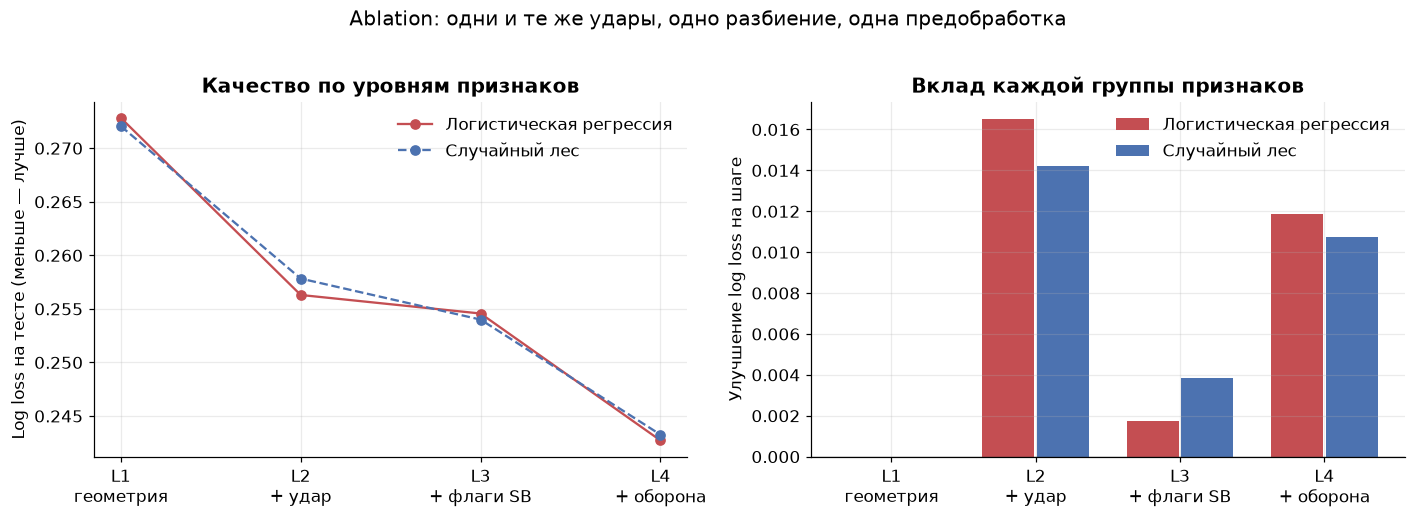

In [5]:
plot_ablation(ablation);

## Неопределённость

Парный bootstrap ресемплирует матчи, а не отдельные удары.
Удары одного матча зависимы, и bootstrap по строкам занизил бы интервалы.

In [6]:
defensive = bootstrap[bootstrap['сравнение'].str.contains('защитный контекст')]
defensive[['сравнение', 'delta_log_loss', 'delta_log_loss_ci_low', 'delta_log_loss_ci_high', 'delta_brier', 'delta_brier_ci_low', 'delta_brier_ci_high']].round(5)

,сравнение,delta_log_loss,delta_log_loss_ci_low,delta_log_loss_ci_high,delta_brier,delta_brier_ci_low,delta_brier_ci_high
2,Логистическая: + защитный контекст (L3 → L4),-0.01185,-0.01603,-0.00784,-0.00287,-0.00410,-0.00166
3,Случайный лес: + защитный контекст (L3 → L4),-0.01075,-0.01532,-0.00629,-0.00278,-0.00421,-0.00160
4,Логистическая: + защитный контекст БЕЗ n_oppon...,-0.01141,-0.01553,-0.00736,-0.00268,-0.00388,-0.00147
5,Случайный лес: + защитный контекст БЕЗ n_oppon...,-0.01034,-0.01489,-0.00620,-0.00255,-0.00393,-0.00137


Оба доверительных интервала целиком лежат ниже нуля.
Улучшение от защитного контекста устойчиво и не объясняется удачным набором матчей в тесте.
Это утверждение о качестве прогноза, а не о причинах.

## Sensitivity test: устойчив ли эффект без `n_opponents_visible`

Признак `n_opponents_visible` неоднозначен.
Он отражает и плотность обороны вокруг момента, и границы поля зрения камеры, задавшие кадр.
Если бы главный эффект держался на нём, вывод пришлось бы пересматривать.
Прирост мог бы объясняться съёмкой, а не игрой.

Поэтому модель обучена дважды, с признаком и без него.
Строки, разбиение и процедура подбора при этом одни и те же.

In [7]:
sensitivity = pd.read_csv(TABLES_DIR / 'sensitivity_visible.csv')
sensitivity.round(5)

,модель,L3 без защитного контекста,L4 без n_opponents_visible,L4 полный,brier_L3,brier_L4_без_visible,brier_L4,roc_auc_L3,roc_auc_L4_без_visible,roc_auc_L4,вклад n_opponents_visible
0,Логистическая регрессия,0.25456,0.24315,0.24271,0.07209,0.06941,0.06922,0.80219,0.82995,0.83004,0.00044
1,Случайный лес,0.25400,0.24366,0.24325,0.07223,0.06968,0.06945,0.80494,0.82954,0.82964,0.00041


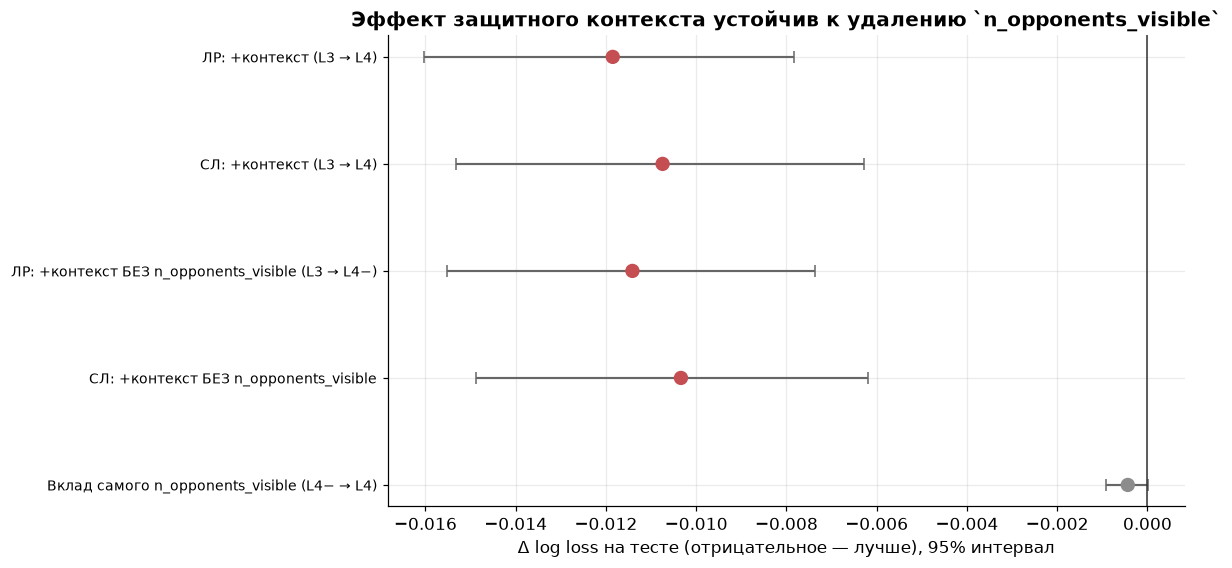

In [8]:
from xg_context.visualization import plot_sensitivity

plot_sensitivity(bootstrap);

Эффект защитного контекста сохраняется без спорного признака.
Интервалы по-прежнему целиком ниже нуля.
Собственный вклад самого `n_opponents_visible` мал, и по log loss его интервал включает ноль.

Главный вывод устойчив.
Он не держится на признаке, который смешивает плотность обороны с границами кадра.
Читать этот признак как "плотность обороны" всё равно нельзя.

## Проверки изоляции

Проверки пересчитываются при каждом запуске `run_experiments.py`.
Они считаются из фактических объектов эксперимента, а не декларируются в тексте.

In [9]:
summary = json.loads((TABLES_DIR / 'experiment_summary.json').read_text(encoding='utf-8'))
pd.DataFrame(summary['isolation_audit'])

,проверка,пройдена
0,"Матчи не пересекаются между train, validation ...",True
1,Удары не пересекаются между train и test,True
2,Тестовые shot_id зафиксированы на диске до оценки,True
3,Выбор лучшей нелинейной модели сделан по valid...,True
4,Гиперпараметры подобраны только внутри train (...,True
5,"Preprocessing обучается внутри Pipeline, то ес...",True
6,Все ablation-модели оценены на одних и тех же ...,True
7,statsbomb_xg не входит ни в один набор признаков,True
8,"Идентичность игрока, команды и лиги не входит ...",True
9,Исход удара и траектория после удара не входят...,True


## Какие защитные признаки важнее

In [10]:
importance = pd.read_csv(TABLES_DIR / 'feature_importance_logistic_geometry_shot_flags_defensive.csv')
importance['признак'] = importance['признак'].str.replace('num__', '', regex=False).str.replace('cat__', '', regex=False)
importance.head(15).round(4)

,признак,коэффициент,модуль
0,shot_distance,-1.6924,1.6924
1,shot_type_Open Play,-1.3730,1.3730
2,body_part_Head,-1.0203,1.0203
3,shot_technique_Backheel,-0.8937,0.8937
4,shot_technique_Overhead Kick,-0.7266,0.7266
5,goalkeeper_distance_to_shot,0.6535,0.6535
6,shot_technique_Diving Header,0.6163,0.6163
7,shot_angle,0.4092,0.4092
8,goalkeeper_distance_to_goal_line,0.4049,0.4049
9,body_part_Other,-0.3839,0.3839


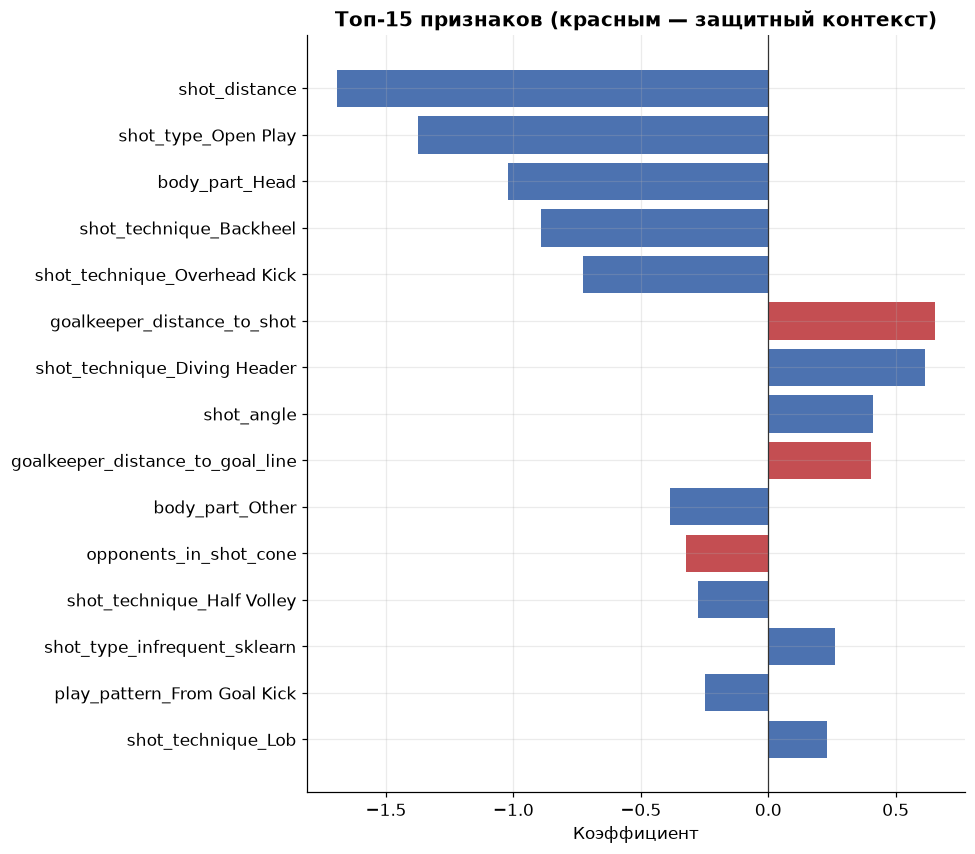

In [11]:
plot_feature_importance(importance);

Коэффициенты нужно читать с оговорками.
Защитные признаки коллинеарны между собой.
Число соперников в радиусах и в конусе описывает одно явление.
Расстояние до ближайшего соперника описывает его же с другой стороны.
Поэтому вклад делится между ними.